# Adjustment factor check

This notebook checks whether the adjustment factor calculated from corporate actions is close to Yahoo's stored `Adj_Close / Close` ratio.

The point is not to use `Adj_Close / Close` in the calculation. The point is to use it as an external check.

In [6]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None):
    # Find the Bluegrey repo root from the notebook's current working directory
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "src" / "data" / "yahoo").exists():
            return path
    raise FileNotFoundError("Could not find repo root containing src/data/yahoo")


# Locate repo paths used by this notebook
repo_root = find_repo_root()
ml_predictor_dir = repo_root / "research" / "Mateo" / "ML_predictor"
yahoo_root = repo_root / "src" / "data" / "yahoo"

# Make ML_predictor.py importable when the notebook is run from another folder
if str(ml_predictor_dir) not in sys.path:
    sys.path.insert(0, str(ml_predictor_dir))

from ML_predictor import MLPredictorStrategy

print(f"Repo root: {repo_root}")
print(f"Yahoo data root: {yahoo_root}")

Repo root: /Users/mateo/Bluegrey
Yahoo data root: /Users/mateo/Bluegrey/src/data/yahoo


In [7]:
def load_yahoo_csv(symbol):
    # Find the single stored Yahoo CSV for this symbol
    csv_matches = sorted(yahoo_root.glob(f"*/1d/{symbol}.csv"))
    if not csv_matches:
        raise FileNotFoundError(f"No Yahoo CSV found for {symbol} under {yahoo_root}")
    if len(csv_matches) > 1:
        raise ValueError(f"Multiple Yahoo CSVs found for {symbol}: {csv_matches}")

    # Load the raw stored data and use Timestamp as the time index
    return pd.read_csv(csv_matches[0], parse_dates=["Timestamp"]).set_index("Timestamp")


def compare_adjustment_factor(symbol):
    # Load raw Yahoo data with Close, Adj_Close, Dividends, and Stock_Splits
    df = load_yahoo_csv(symbol)

    # Calculate the action-built factor from the function in ML_predictor.py
    strategy = MLPredictorStrategy(params={"symbol": symbol, "verbose": False})
    action_factor = strategy.calculate_adjustment_factor(df)

    # Use Yahoo's Adj_Close / Close only as a check, not as the calculation
    yahoo_ratio = (df["Adj_Close"] / df["Close"]).replace([np.inf, -np.inf], np.nan)

    # Put both factors side by side and calculate their difference
    comparison = pd.DataFrame(
        {
            "Action_Factor": action_factor,
            "Yahoo_Ratio": yahoo_ratio,
        }
    )
    comparison["Difference"] = comparison["Action_Factor"] - comparison["Yahoo_Ratio"]
    comparison["Abs_Difference"] = comparison["Difference"].abs()

    # Summarize the size of the mismatch
    summary = {
        "Symbol": symbol,
        "Rows": len(comparison),
        "Dividend_Days": int(df["Dividends"].fillna(0.0).ne(0.0).sum()),
        "Split_Days": int(df["Stock_Splits"].fillna(0.0).ne(0.0).sum()),
        "Max_Abs_Difference": comparison["Abs_Difference"].max(),
        "Mean_Abs_Difference": comparison["Abs_Difference"].mean(),
        "First_Action_Factor": comparison["Action_Factor"].iloc[0],
        "First_Yahoo_Ratio": comparison["Yahoo_Ratio"].iloc[0],
    }

    return df, comparison, summary

In [8]:
# ECH is useful for dividend adjustments; AAPL is useful because it has split history too
symbols = ["ECH", "AAPL"]

results = {}
summaries = []

for symbol in symbols:
    df, comparison, summary = compare_adjustment_factor(symbol)
    results[symbol] = {"df": df, "comparison": comparison}
    summaries.append(summary)

# If the function is working, Max_Abs_Difference should be very small
summary_df = pd.DataFrame(summaries)
summary_df

,Symbol,Rows,Dividend_Days,Split_Days,Max_Abs_Difference,Mean_Abs_Difference,First_Action_Factor,First_Yahoo_Ratio
0,ECH,4683,43,0,3.705336e-07,7.058589e-08,0.642259,0.642259
1,AAPL,11481,91,5,8.209741e-07,1.271206e-07,0.765162,0.765162


In [9]:
for symbol in symbols:
    df = results[symbol]["df"]
    comparison = results[symbol]["comparison"]

    # Show recent corporate action dates so the adjustment inputs are visible
    action_rows = df.loc[
        df["Dividends"].fillna(0.0).ne(0.0) | df["Stock_Splits"].fillna(0.0).ne(0.0),
        ["Close", "Adj_Close", "Dividends", "Stock_Splits"],
    ].tail(10)

    # Show the rows where the two factors differ the most
    largest_diffs = comparison.sort_values("Abs_Difference", ascending=False).head(10)

    print(f"\n{symbol}: recent corporate action rows")
    display(action_rows)

    print(f"{symbol}: largest factor differences")
    display(largest_diffs)


ECH: recent corporate action rows


,Close,Adj_Close,Dividends,Stock_Splits
Timestamp,,,,
2022-06-09,28.280001,24.567459,1.135,0.0
2022-12-13,26.760000,23.855764,0.689,0.0
2023-06-07,29.299999,27.173492,1.168,0.0
2023-12-20,27.379999,25.552258,0.176,0.0
2024-06-11,26.910000,25.755451,0.698,0.0
2024-12-17,25.410000,24.399900,0.084,0.0
2025-06-16,31.110001,30.517609,0.672,0.0
2025-12-16,38.840000,38.162064,0.063,0.0
2025-12-30,40.540001,39.909924,0.078,0.0


ECH: largest factor differences


,Action_Factor,Yahoo_Ratio,Difference,Abs_Difference
Timestamp,,,,
2014-02-19,0.696034,0.696033,3.705336e-07,3.705336e-07
2014-02-25,0.696034,0.696033,3.705336e-07,3.705336e-07
2017-02-01,0.733336,0.733335,3.549309e-07,3.549309e-07
2017-06-26,0.745247,0.745247,3.429769e-07,3.429769e-07
2008-09-19,0.650005,0.650004,3.395212e-07,3.395212e-07
2017-08-15,0.745247,0.745247,3.351911e-07,3.351911e-07
2017-08-31,0.745247,0.745247,3.166079e-07,3.166079e-07
2017-09-26,0.745247,0.745247,3.166079e-07,3.166079e-07
2008-01-22,0.642902,0.642903,-3.119079e-07,3.119079e-07



AAPL: recent corporate action rows


,Close,Adj_Close,Dividends,Stock_Splits
Timestamp,,,,
2024-02-09,188.850006,186.974564,0.24,0.0
2024-05-10,183.050003,181.477951,0.25,0.0
2024-08-12,217.529999,215.911453,0.25,0.0
2024-11-08,226.960007,225.519150,0.25,0.0
2025-02-10,227.649994,226.453461,0.25,0.0
2025-05-12,210.789993,209.957047,0.26,0.0
2025-08-11,227.179993,226.539108,0.26,0.0
2025-11-10,269.429993,268.930359,0.26,0.0
2026-02-09,274.619995,274.367218,0.26,0.0


AAPL: largest factor differences


,Action_Factor,Yahoo_Ratio,Difference,Abs_Difference
Timestamp,,,,
2014-02-18,0.872068,0.872069,-8.209741e-07,8.209741e-07
1987-12-18,0.768991,0.768991,-7.714327e-07,7.714327e-07
1990-07-09,0.787847,0.787848,-6.500965e-07,6.500965e-07
1987-04-24,0.765162,0.765163,-6.400748e-07,6.400748e-07
1987-04-21,0.765162,0.765163,-6.400748e-07,6.400748e-07
1989-05-02,0.777667,0.777667,-6.399044e-07,6.399044e-07
1988-08-02,0.772032,0.772032,-6.334181e-07,6.334181e-07
1988-08-04,0.772032,0.772032,-6.334181e-07,6.334181e-07
2017-03-10,0.924222,0.924222,-6.238604e-07,6.238604e-07


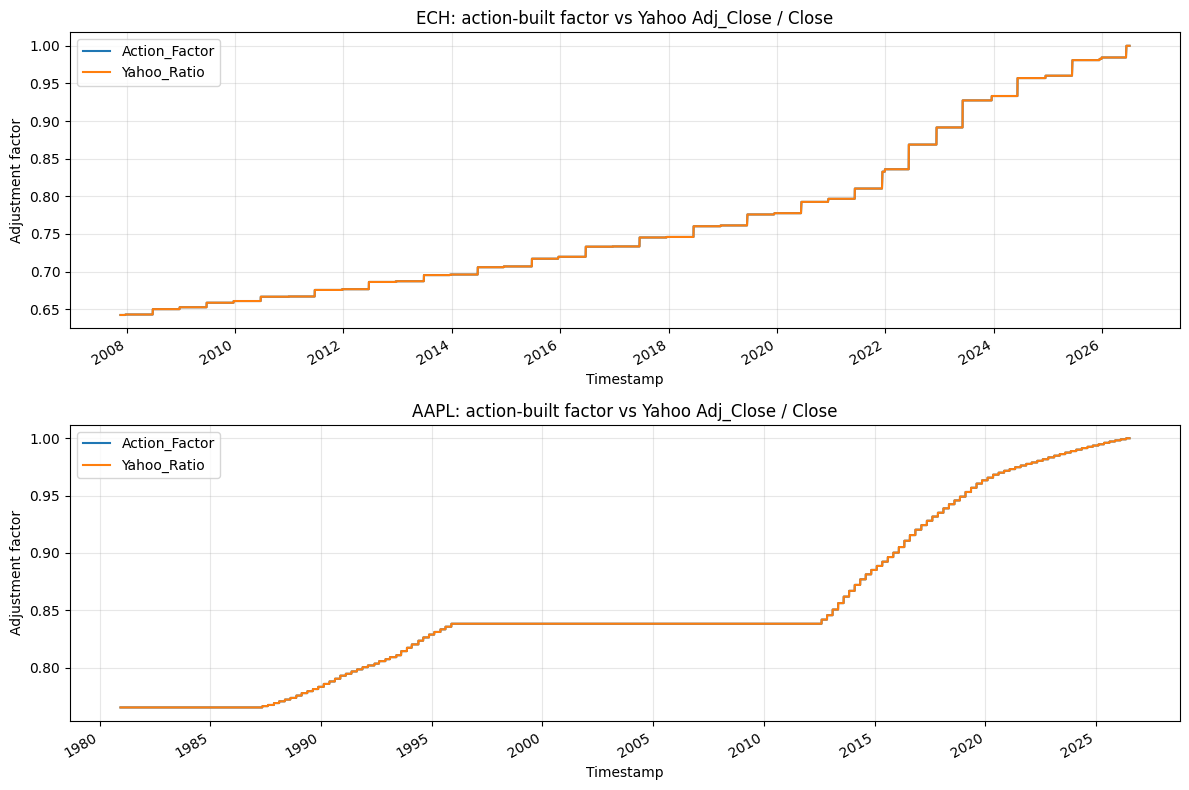

In [10]:
fig, axes = plt.subplots(len(symbols), 1, figsize=(12, 4 * len(symbols)), sharex=False)

if len(symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols):
    comparison = results[symbol]["comparison"]

    # Plot both factors; if they match, the lines should sit on top of each other
    comparison[["Action_Factor", "Yahoo_Ratio"]].plot(ax=ax)
    ax.set_title(f"{symbol}: action-built factor vs Yahoo Adj_Close / Close")
    ax.set_ylabel("Adjustment factor")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

## What if we include stock splits?

This section intentionally calculates a factor that also reapplies `Stock_Splits`.

For Yahoo/yfinance daily OHLC data, this should be wrong because the OHLC prices are already split-adjusted even when `auto_adjust=False`.

In [11]:
def calculate_factor_with_splits(df):
    # Work on a date-sorted copy because cumulative adjustments depend on time order
    actions_df = df[["Close", "Dividends", "Capital_Gains", "Stock_Splits"]].copy().sort_index()

    # Convert inputs to numeric values and treat missing actions as no action
    close = pd.to_numeric(actions_df["Close"], errors="coerce")
    dividends = pd.to_numeric(actions_df["Dividends"], errors="coerce").fillna(0.0)
    capital_gains = pd.to_numeric(actions_df["Capital_Gains"], errors="coerce").fillna(0.0)
    stock_splits = pd.to_numeric(actions_df["Stock_Splits"], errors="coerce").fillna(0.0)

    # Start with no adjustment on every date
    event_factor = pd.Series(1.0, index=actions_df.index)

    # Apply cash distributions the same way as the real helper
    previous_close = close.shift(1)
    cash_distributions = dividends + capital_gains
    distribution_factor = (previous_close - cash_distributions) / previous_close
    valid_distribution = cash_distributions.ne(0.0) & previous_close.notna() & previous_close.ne(0.0)
    event_factor.loc[valid_distribution] *= distribution_factor.loc[valid_distribution]

    # Intentionally wrong for Yahoo OHLC: reapply split ratios that are already reflected in prices
    valid_split = stock_splits.notna() & stock_splits.ne(0.0) & stock_splits.ne(1.0)
    event_factor.loc[valid_split] /= stock_splits.loc[valid_split]

    # Apply each event only to dates before the event date, not to the event date itself
    split_inclusive_factor = event_factor.iloc[::-1].cumprod().iloc[::-1] / event_factor

    # Return the factor in the same row order as the input DataFrame
    return split_inclusive_factor.reindex(df.index)


split_summaries = []

for symbol in symbols:
    df = results[symbol]["df"]
    comparison = results[symbol]["comparison"].copy()

    # Add the intentionally wrong split-inclusive factor
    comparison["Factor_With_Splits"] = calculate_factor_with_splits(df)
    comparison["Split_Inclusive_Difference"] = comparison["Factor_With_Splits"] - comparison["Yahoo_Ratio"]
    comparison["Split_Inclusive_Abs_Difference"] = comparison["Split_Inclusive_Difference"].abs()
    results[symbol]["split_comparison"] = comparison

    # Summarize how much worse the split-inclusive factor is
    split_summaries.append(
        {
            "Symbol": symbol,
            "Split_Days": int(df["Stock_Splits"].fillna(0.0).ne(0.0).sum()),
            "Correct_Max_Abs_Difference": comparison["Abs_Difference"].max(),
            "With_Splits_Max_Abs_Difference": comparison["Split_Inclusive_Abs_Difference"].max(),
            "First_Yahoo_Ratio": comparison["Yahoo_Ratio"].iloc[0],
            "First_Factor_With_Splits": comparison["Factor_With_Splits"].iloc[0],
        }
    )

pd.DataFrame(split_summaries)

,Symbol,Split_Days,Correct_Max_Abs_Difference,With_Splits_Max_Abs_Difference,First_Yahoo_Ratio,First_Factor_With_Splits
0,ECH,0,3.705336e-07,3.705336e-07,0.642259,0.642259
1,AAPL,5,8.209741e-07,8.456199e-01,0.765162,0.003416


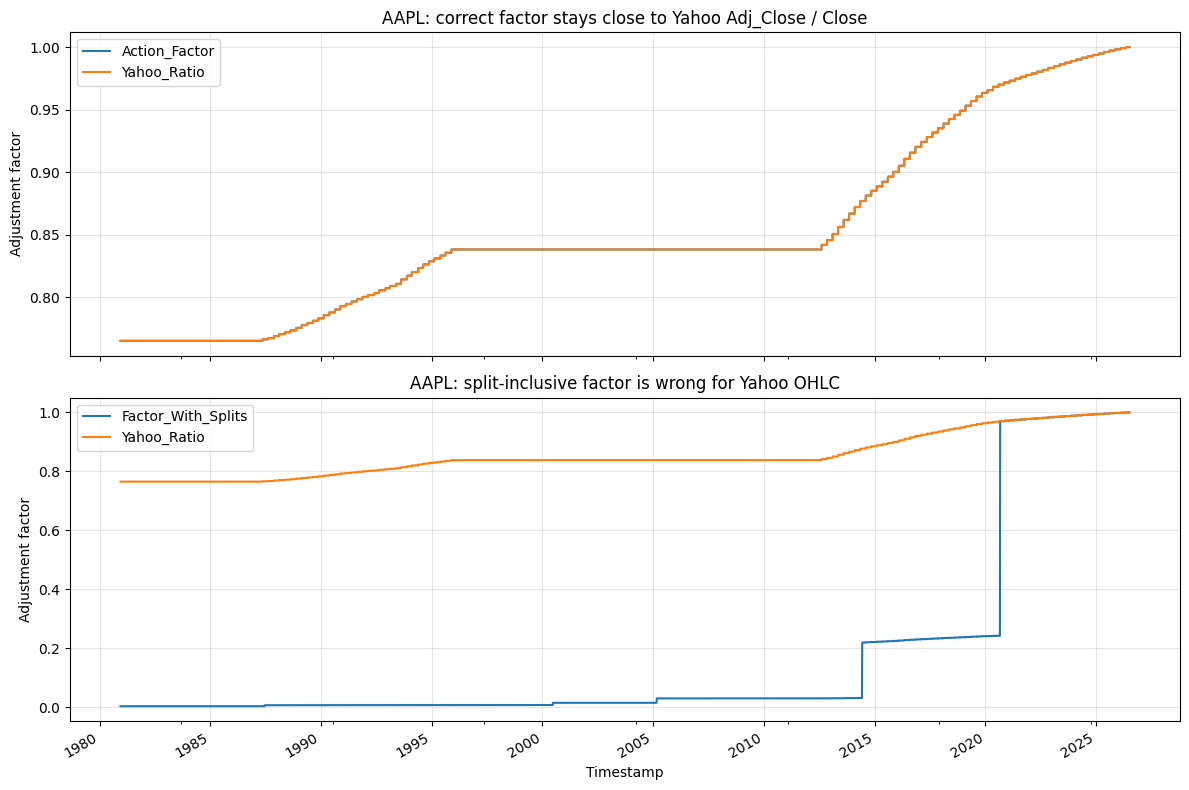

In [12]:
# AAPL has multiple historical splits, so it makes the double-adjustment problem obvious
symbol = "AAPL"
comparison = results[symbol]["split_comparison"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# The correct action factor should sit on top of Yahoo's ratio
comparison[["Action_Factor", "Yahoo_Ratio"]].plot(ax=axes[0])
axes[0].set_title(f"{symbol}: correct factor stays close to Yahoo Adj_Close / Close")
axes[0].set_ylabel("Adjustment factor")
axes[0].grid(True, alpha=0.3)

# The split-inclusive factor should separate because it adjusts split history twice
comparison[["Factor_With_Splits", "Yahoo_Ratio"]].plot(ax=axes[1])
axes[1].set_title(f"{symbol}: split-inclusive factor is wrong for Yahoo OHLC")
axes[1].set_ylabel("Adjustment factor")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

Interpretation:

- `Action_Factor` is calculated from corporate actions by `calculate_adjustment_factor()`.
- `Yahoo_Ratio` is `Adj_Close / Close`, used only as a check.
- Very small differences are expected because of floating-point precision and Yahoo's own rounded stored values.
- `Capital_Gains` is included with dividends when present, because it is also a cash distribution.
- `Stock_Splits` is displayed, but the function does not reapply splits because Yahoo/yfinance OHLC prices are already split-adjusted.